<a href="https://colab.research.google.com/github/asegura4488/EDCO_MachineLearning/blob/main/Semana1/QuejasAmbientales_leakage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Como cargar el drive en python, comment
# Sintaxis -> una forma de escribir

from google.colab import drive
from google.colab import files
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Necesitamos explorar la estructura de directorios
import os
# Necesito ir a la carpeta del curso
os.chdir('/content/drive/MyDrive/EDCO_MachineLearning/Semana1/')

In [ ]:
import pandas as pd
datos = pd.read_csv('Data/QuejasAmbientales.csv')

In [ ]:
datos

,REGIONAL,MEDIO DE RECEPCION,TIPO DE AFECTACION,RECURSO AFECTADO,MUNICIPIO,Periodo
0,Bosques,Telefónico,TALA BOSQUE NATURAL NATIVO,FLORA,SAN LUIS,2021
1,Aguas,Pagina Web,CONFLICTOS POR USO DEL AGUA,AGUA,SAN RAFAEL,2021
2,Bosques,Pagina Web,TALA BOSQUE NATURAL NATIVO,FLORA,SAN LUIS,2021
3,Bosques,Telefónico,CONTAMINACION DEL AGUA,AGUA,PUERTO TRIUNFO,2021
4,Paramo,Pagina Web,CONTAMINACIÓN POR VERTIMIENTOS,SUELO,SONSÓN,2021
...,...,...,...,...,...,...
1800,Valles,Correo electrónico,CONTAMINACIÓN POR VERTIMIENTOS,AGUA,GUARNE,2021
1801,Valles,Correo electrónico,TALA BOSQUE NATURAL NATIVO,FLORA,GUARNE,2021
1802,Valles,Correo electrónico,MOVIMIENTO DE TIERRAS,AGUA,LA CEJA,2021
1803,Aguas,Correo electrónico,MOVIMIENTO DE TIERRAS,AGUA,GUATAPÉ,2021


In [ ]:
##### La paqueteria!!!!
import matplotlib.pyplot as plt

#
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier # Problema de classificacion

from sklearn.tree import plot_tree

# Necesitamos metricas
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
datos.keys()

Index(['REGIONAL', 'MEDIO DE  RECEPCION', 'TIPO DE AFECTACION',
       'RECURSO AFECTADO', 'MUNICIPIO', 'Periodo'],
      dtype='object')

In [ ]:
columnas_texto = [
    "REGIONAL",
    "TIPO DE AFECTACION",
    "RECURSO AFECTADO",
    "MUNICIPIO",
    "MEDIO DE  RECEPCION"
]

In [ ]:
for columna in columnas_texto:

  datos[columna] = datos[columna].str.strip()
  # Quitar los espacios al comienzo y al final # Mineria

  # Todo en mayusculas
  datos[columna] = datos[columna].str.upper()


In [ ]:
datos

,REGIONAL,MEDIO DE RECEPCION,TIPO DE AFECTACION,RECURSO AFECTADO,MUNICIPIO,Periodo
0,BOSQUES,TELEFÓNICO,TALA BOSQUE NATURAL NATIVO,FLORA,SAN LUIS,2021
1,AGUAS,PAGINA WEB,CONFLICTOS POR USO DEL AGUA,AGUA,SAN RAFAEL,2021
2,BOSQUES,PAGINA WEB,TALA BOSQUE NATURAL NATIVO,FLORA,SAN LUIS,2021
3,BOSQUES,TELEFÓNICO,CONTAMINACION DEL AGUA,AGUA,PUERTO TRIUNFO,2021
4,PARAMO,PAGINA WEB,CONTAMINACIÓN POR VERTIMIENTOS,SUELO,SONSÓN,2021
...,...,...,...,...,...,...
1800,VALLES,CORREO ELECTRÓNICO,CONTAMINACIÓN POR VERTIMIENTOS,AGUA,GUARNE,2021
1801,VALLES,CORREO ELECTRÓNICO,TALA BOSQUE NATURAL NATIVO,FLORA,GUARNE,2021
1802,VALLES,CORREO ELECTRÓNICO,MOVIMIENTO DE TIERRAS,AGUA,LA CEJA,2021
1803,AGUAS,CORREO ELECTRÓNICO,MOVIMIENTO DE TIERRAS,AGUA,GUATAPÉ,2021


In [ ]:
# Es la variable a predecir
datos['ES_TELEFONICA'] = (datos['MEDIO DE  RECEPCION'] == "TELEFÓNICO").astype(int)

In [ ]:
datos

,REGIONAL,MEDIO DE RECEPCION,TIPO DE AFECTACION,RECURSO AFECTADO,MUNICIPIO,Periodo,ES_TELEFONICA
0,BOSQUES,TELEFÓNICO,TALA BOSQUE NATURAL NATIVO,FLORA,SAN LUIS,2021,1
1,AGUAS,PAGINA WEB,CONFLICTOS POR USO DEL AGUA,AGUA,SAN RAFAEL,2021,0
2,BOSQUES,PAGINA WEB,TALA BOSQUE NATURAL NATIVO,FLORA,SAN LUIS,2021,0
3,BOSQUES,TELEFÓNICO,CONTAMINACION DEL AGUA,AGUA,PUERTO TRIUNFO,2021,1
4,PARAMO,PAGINA WEB,CONTAMINACIÓN POR VERTIMIENTOS,SUELO,SONSÓN,2021,0
...,...,...,...,...,...,...,...
1800,VALLES,CORREO ELECTRÓNICO,CONTAMINACIÓN POR VERTIMIENTOS,AGUA,GUARNE,2021,0
1801,VALLES,CORREO ELECTRÓNICO,TALA BOSQUE NATURAL NATIVO,FLORA,GUARNE,2021,0
1802,VALLES,CORREO ELECTRÓNICO,MOVIMIENTO DE TIERRAS,AGUA,LA CEJA,2021,0
1803,AGUAS,CORREO ELECTRÓNICO,MOVIMIENTO DE TIERRAS,AGUA,GUATAPÉ,2021,0


In [ ]:
datos['ES_TELEFONICA'].value_counts()

,count
ES_TELEFONICA,
1,971
0,834


In [ ]:
datos['ES_TELEFONICA'].value_counts( normalize = True )

,proportion
ES_TELEFONICA,
1,0.53795
0,0.46205


In [ ]:
# Vamos a preparar las variables explicativas
variables_entrada = [
    "REGIONAL",
    "TIPO DE AFECTACION",
    "RECURSO AFECTADO",
    "MUNICIPIO",
    "MEDIO DE  RECEPCION" # Agregamos artificialmente la informacion del leakage
]

In [ ]:
# la informacion de entrada al modelo
X = datos[variables_entrada]
X

,REGIONAL,TIPO DE AFECTACION,RECURSO AFECTADO,MUNICIPIO,MEDIO DE RECEPCION
0,BOSQUES,TALA BOSQUE NATURAL NATIVO,FLORA,SAN LUIS,TELEFÓNICO
1,AGUAS,CONFLICTOS POR USO DEL AGUA,AGUA,SAN RAFAEL,PAGINA WEB
2,BOSQUES,TALA BOSQUE NATURAL NATIVO,FLORA,SAN LUIS,PAGINA WEB
3,BOSQUES,CONTAMINACION DEL AGUA,AGUA,PUERTO TRIUNFO,TELEFÓNICO
4,PARAMO,CONTAMINACIÓN POR VERTIMIENTOS,SUELO,SONSÓN,PAGINA WEB
...,...,...,...,...,...
1800,VALLES,CONTAMINACIÓN POR VERTIMIENTOS,AGUA,GUARNE,CORREO ELECTRÓNICO
1801,VALLES,TALA BOSQUE NATURAL NATIVO,FLORA,GUARNE,CORREO ELECTRÓNICO
1802,VALLES,MOVIMIENTO DE TIERRAS,AGUA,LA CEJA,CORREO ELECTRÓNICO
1803,AGUAS,MOVIMIENTO DE TIERRAS,AGUA,GUATAPÉ,CORREO ELECTRÓNICO


In [ ]:
# la respuesta que queremos predecir
Y = datos['ES_TELEFONICA']

In [ ]:
Y

,ES_TELEFONICA
0,1
1,0
2,0
3,1
4,0
...,...
1800,0
1801,0
1802,0
1803,0


In [ ]:
# Codificacion -> one-hot encoding
X = pd.get_dummies(X, dtype=int)
X

,REGIONAL_AGUAS,REGIONAL_BOSQUES,REGIONAL_PARAMO,REGIONAL_PORCE,REGIONAL_VALLES,TIPO DE AFECTACION_CONFLICTOS POR USO DEL AGUA,TIPO DE AFECTACION_CONTAMINACION DEL AGUA,TIPO DE AFECTACION_CONTAMINACIÓN POR VERTIMIENTOS,TIPO DE AFECTACION_DESCORTEZADO DE ÁRBOLES,TIPO DE AFECTACION_EMISION ATMOSFÉRICA,...,MUNICIPIO_SAN ROQUE,MUNICIPIO_SAN VICENTE,MUNICIPIO_SANTO DOMINGO,MUNICIPIO_SONSÓN,MEDIO DE RECEPCION_CORREO ELECTRÓNICO,MEDIO DE RECEPCION_DE OFICIO,MEDIO DE RECEPCION_ESCRITA,MEDIO DE RECEPCION_PAGINA WEB,MEDIO DE RECEPCION_PERSONAL,MEDIO DE RECEPCION_TELEFÓNICO
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,1,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1800,0,0,0,0,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
1801,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1802,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1803,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
# Dividir los datos en entrenamiento y prueba
X_entrenamiento, X_prueba, Y_entrenamiento, Y_prueba = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
# random_state=42, reproducibilidad

In [ ]:
Y.value_counts()

,count
ES_TELEFONICA,
1,971
0,834


In [ ]:
# Vamos a definir el modelo
modelo = DecisionTreeClassifier(
    max_depth=4, # Un hiperparametro -> toca optimizarlo
    min_samples_leaf=10, # Un hiperparametro
    random_state=42
)

In [ ]:
# Entrenar el modelo con los datos
modelo.fit(X_entrenamiento, Y_entrenamiento)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42)

In [ ]:
predicciones = modelo.predict(X_prueba)
predicciones

array([1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0,

In [ ]:
# Necesitamos el concepto de metrica
exactitud_modelo = accuracy_score(Y_prueba, predicciones)
exactitud_modelo

1.0

In [ ]:
#QUe mejora tuvimos
clase_mayoritaria = Y_entrenamiento.mode()[0]
clase_mayoritaria

np.int64(1)

In [ ]:
prediccion_basica = [clase_mayoritaria] * len(Y_prueba)

exactitud_basica = accuracy_score(Y_prueba, prediccion_basica)
exactitud_basica

0.5373961218836565

In [ ]:
mejora = exactitud_modelo - exactitud_basica
mejora

0.4626038781163435

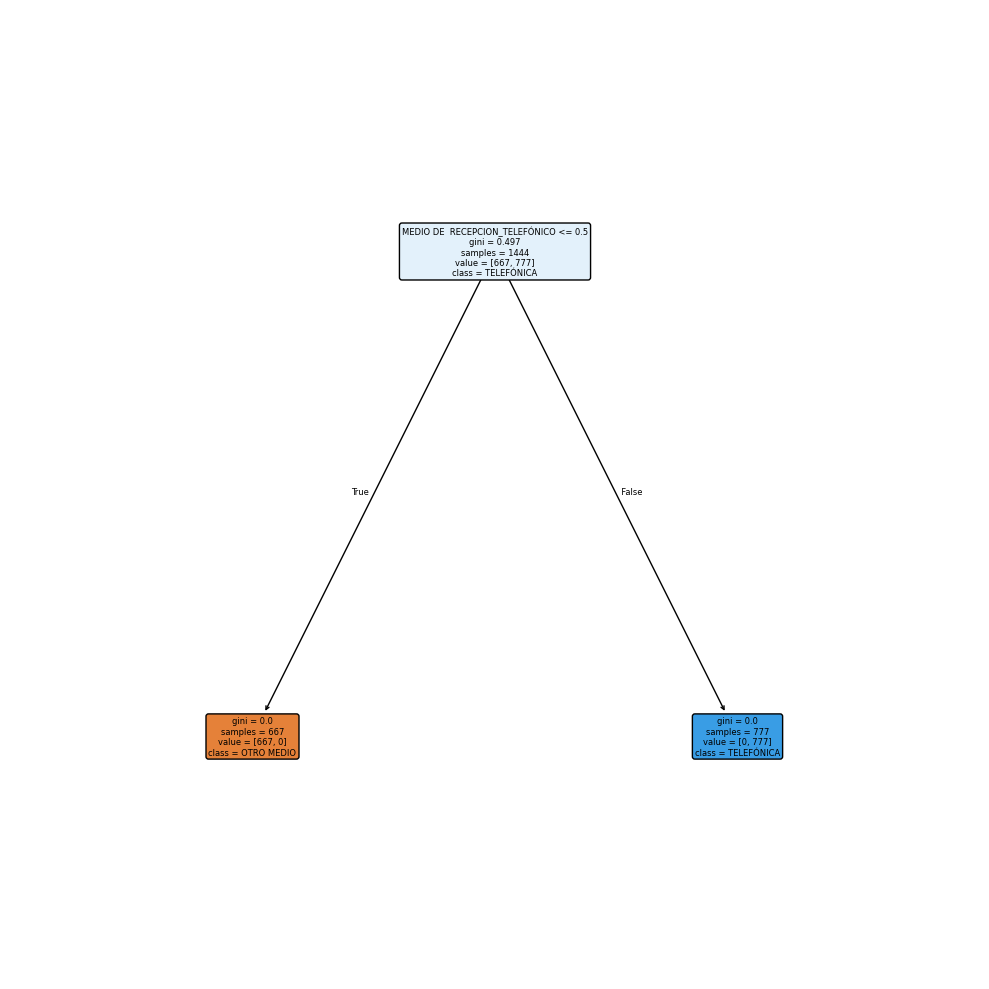

In [ ]:
# Como dibujar el modelo
plt.figure( figsize=(10, 10) )
plot_tree(modelo,
          feature_names=X.columns,
          filled=True,
          class_names=["OTRO MEDIO", "TELEFÓNICA"],
          rounded=True,
          #impurity=False,
          fontsize=6)
plt.tight_layout()
plt.show()

In [ ]:
importancias = pd.DataFrame(modelo.feature_importances_, index=X.columns)
importancias.head(10)

,0
REGIONAL_AGUAS,0.0
REGIONAL_BOSQUES,0.0
REGIONAL_PARAMO,0.0
REGIONAL_PORCE,0.0
REGIONAL_VALLES,0.0
TIPO DE AFECTACION_CONFLICTOS POR USO DEL AGUA,0.0
TIPO DE AFECTACION_CONTAMINACION DEL AGUA,0.0
TIPO DE AFECTACION_CONTAMINACIÓN POR VERTIMIENTOS,0.0
TIPO DE AFECTACION_DESCORTEZADO DE ÁRBOLES,0.0
TIPO DE AFECTACION_EMISION ATMOSFÉRICA,0.0


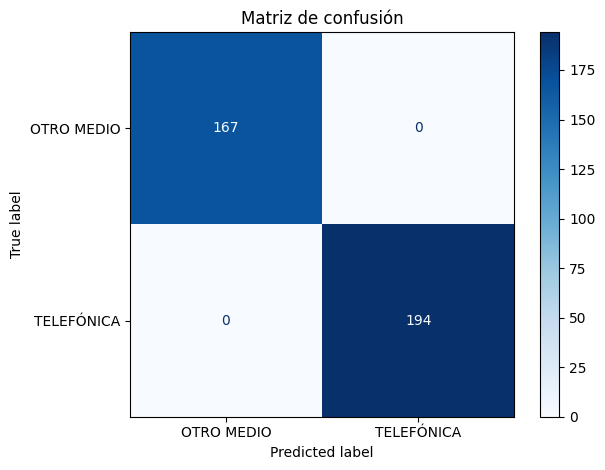

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    Y_prueba,
    predicciones,
    display_labels=["OTRO MEDIO", "TELEFÓNICA"],
    cmap="Blues"
)

plt.title("Matriz de confusión")

plt.tight_layout()

plt.show()
